# LDA Model
## Marissa Burton

### Import packages

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation as LDA, NMF

### Set OHCO

In [63]:
model_type = 'lda'
OHCO = ['era','book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:4]
CHAP = OHCO[:3]
BOOK = OHCO[:2]
ERA = OHCO[:1]
BAG = CHAP

### Load in CORPUS

In [64]:
CORPUS = pd.read_csv('data/CORPUS.csv').dropna(subset=['term_str'])

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_65228/1642426331.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  CORPUS = pd.read_csv('data/CORPUS.csv').dropna(subset=['term_str'])


### Create DOCS table and filter for nouns

In [65]:
DOCS = CORPUS.groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

### Set stop words

In [66]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))

### Create Vector Space

In [67]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

17  abandoned  able  abroad  \
era                       book_id chap_num                                
classical/romantic gothic 6087    1          0          0     0       0   
                                  3          0          0     0       0   
                                  4          0          0     0       0   
                          41445   1          0          0     0       0   
                                  2          0          0     0       0   
...                                         ..        ...   ...     ...   
victorian gothic          345     24         0          0     4       0   
                                  25         1          0     0       0   
                                  26         0          0     2       0   
                                  27         0          0     1       0   
                          1952    0          0          0     4       0   

                                            abruptly  absence  absent  \
era                       book_id chap_num                              
classical/romantic gothic 6087    1                0        0       0   
                                  3                0        0       0   
                                  4                1        1       0   
                          41445   1                0        0       1   
                                  2                0        0       0   
...                                              ...      ...     ...   
victorian gothic          345     24               0        0       0   
                                  25               0        0       0   
                                  26               0        0       0   
                                  27               0        0       0   
                          1952    0                0        0       0   

                                            absolute  absolutely  absorbed  \
era                       book_id chap_num                                   
classical/romantic gothic 6087    1                0           0         0   
                                  3                0           0         0   
                                  4                0           0         3   
                          41445   1                0           0         0   
                                  2                0           0         0   
...                                              ...         ...       ...   
victorian gothic          345     24               0           0         0   
                                  25               1           0         0   
                                  26               0           0         0   
                                  27               0           0         0   
                          1952    0                0           1         0   

                                            ...  years  yellow  yesterday  \
era                       book_id chap_num  ...                             
classical/romantic gothic 6087    1         ...      1       0          0   
                                  3         ...      1       1          0   
                                  4         ...      1       0          0   
                          41445   1         ...      9       0          0   
                                  2         ...      2       0          0   
...                                         ...    ...     ...        ...   
victorian gothic          345     24        ...      1       0          2   
                                  25        ...      0       0          1   
                                  26        ...      1       0          0   
                                  27        ...      2       1          2   
                          1952    0         ...      1       8          0   

                                            yield  yielded  young  younger  \
era                    

### Generate Model

In [68]:
n_topics = 20
max_iter = 100
n_top_terms = 5
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [69]:
topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

### THETA

In [70]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap='Blues')

### PHI

In [71]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap='Blues')

term_str,wolves,guarded,bearing,yard,quietly,confined,connection,contracted,scream,persuade
topic_id,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.050000,1.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T01,0.050000,0.050000,1.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T02,0.050000,3.225264,6.918751,0.050000,1.132417,0.050000,0.050000,0.050000,0.050000,2.280167
T03,0.050000,0.050000,2.341588,1.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T04,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,1.050000,0.050000,1.996364
T05,0.050000,0.050000,0.050000,0.050000,3.050000,0.050000,0.050000,1.050000,0.050000,0.050000
T06,0.050000,0.050000,0.050000,0.050000,13.668055,0.050000,0.050000,0.050000,7.896099,0.050000
T07,0.050000,2.630472,0.050000,1.539238,5.630701,0.050000,1.913244,0.050000,0.050000,1.804425
T08,0.050000,0.050000,1.050000,1.050000,0.050000,0.050000,0.050000,1.050000,2.050000,0.050000


### TOPICS

In [73]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')\
    .dropna()\
    .drop_duplicates()
TOPICS

,top_terms
topic_id,
T00,ghost box opera richard head
T01,persian raoul sir christine daae
T02,heard door shall lord sister
T03,forest cottage light wood branches
T04,richard moncharmin ghost giry box
T05,john old dying uncle kitchen
T06,house doctor door mrs hill
T07,christine raoul erik voice persian
T08,old family house saw room


#### TOPICS sorted by document weights

In [74]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

,top_terms,doc_weight_sum,term_freq
topic_id,,,
T19,door room night came mr,16.626989,0.123812
T06,house doctor door mrs hill,14.682439,0.126727
T12,shall van helsing lucy come,14.539636,0.132250
T07,christine raoul erik voice persian,13.335766,0.071169
T14,father life moment god felt,12.360343,0.109833
T18,st aubert emily valancourt till,10.822231,0.094205
T16,elizabeth shall miserable feelings clerval,7.609255,0.038255
T09,sir lord shall father son,6.876757,0.127636
T04,richard moncharmin ghost giry box,5.207285,0.024491


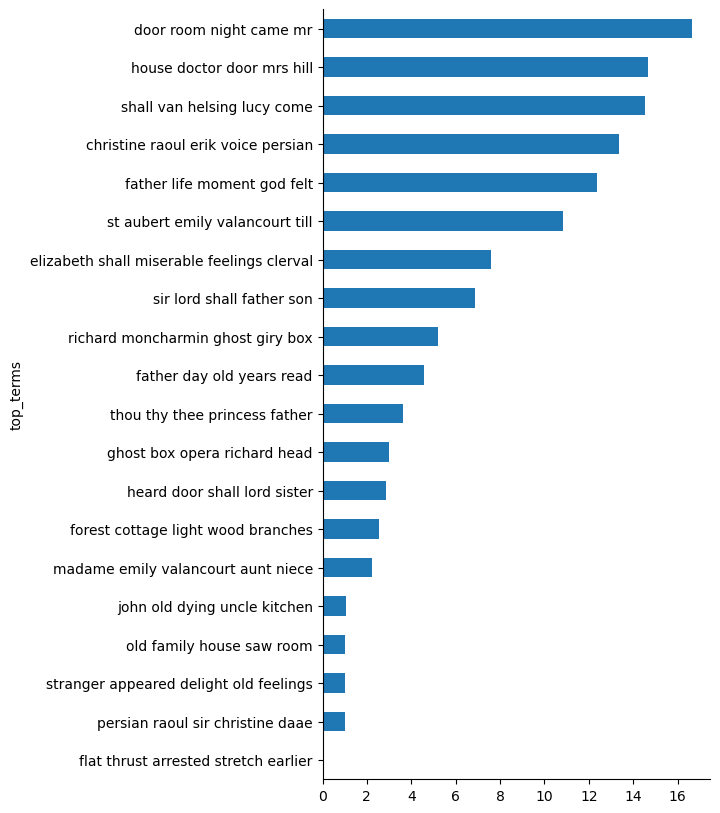

In [75]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

### PCA on LDA

In [76]:
THETAX = THETA.T

In [77]:
pca_engine = PCA(n_components=5)
DCM = pd.DataFrame(pca_engine.fit_transform(THETAX), index=THETAX.index)
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]
DCM['mean_weight'] = THETA.mean(axis=0)
DCM

,PC0,PC1,PC2,PC3,PC4,mean_weight
topic_id,,,,,,
T00,-0.267171,-0.159978,0.003644,-0.373943,-0.463259,0.024002
T01,-0.216203,-0.123453,0.002713,-0.267072,-0.268888,0.008041
T02,-0.178124,-0.103823,0.025039,-0.285422,0.001708,0.022709
T03,-0.247527,-0.106024,0.000593,-0.311958,-0.252778,0.020339
T04,-0.420217,0.286040,-0.096283,-0.211878,-0.596349,0.041658
T05,-0.213876,-0.123724,0.002960,-0.269074,-0.252763,0.008638
T06,1.272185,0.470298,2.479491,0.618122,-0.205741,0.117460
T07,-0.931594,2.604997,-0.536470,0.956943,0.152396,0.106686
T08,-0.216231,-0.123472,0.002713,-0.267123,-0.268964,0.008046


In [78]:
LIB = pd.read_csv('data/LIB.csv')

In [79]:
LIB

,book_id,source_file_path,era,author,title,book_len,n_chaps
0,43,data/source_file_dir/STEVENSON_ROBERT_LOUIS_TH...,victorian gothic,"STEVENSON, ROBERT LOUIS",THE STRANGE CASE OF DR JEKYLL AND MR HYDE,25798,9
1,175,data/source_file_dir/LEROUX_GASTON_THE_PHANTOM...,modern gothic,"LEROUX, GASTON",THE PHANTOM OF THE OPERA,83686,26
2,345,data/source_file_dir/STOKER_BRAM_DRACULA-pg345...,victorian gothic,"STOKER, BRAM",DRACULA,162932,27
3,696,data/source_file_dir/WALPOLE_HORACE_THE_CASTLE...,high gothic,"WALPOLE, HORACE",THE CASTLE OF OTRANTO,34654,5
4,1952,data/source_file_dir/GILMAN_CHARLOTTE_PERKINS_...,victorian gothic,"GILMAN, CHARLOTTE PERKINS",THE YELLOW WALLPAPER,6193,1
5,3268,data/source_file_dir/RADCLIFFE_ANN_WARD_THE_MY...,high gothic,"RADCLIFFE, ANN WARD",THE MYSTERIES OF UDOLPHO,70534,13
6,5182,data/source_file_dir/REEVE_CLARA_THE_OLD_ENGLI...,high gothic,"REEVE, CLARA",THE OLD ENGLISH BARON A GOTHIC STORY,55191,1
7,6087,data/source_file_dir/POLIDORI_JOHN_WILLIAM_THE...,classical/romantic gothic,"POLIDORI, JOHN WILLIAM",THE VAMPYRE,11065,4
8,12122,data/source_file_dir/JACOBS_W_W_THE_MONKEY'S_P...,modern gothic,"JACOBS, W.W.",THE MONKEY'S PAW,4023,3
9,41445,data/source_file_dir/SHELLEY_MARY_WOLLSTONECRA...,classical/romantic gothic,"SHELLEY, MARY WOLLSTONECRAFT",FRANKENSTEIN,67204,23


In [80]:
era_series = THETA.index.get_level_values('era')

topic_to_era = {}

for topic in THETA.columns:
    weights = THETA[topic]

    era_weights = weights.groupby(era_series).sum()
    
    dominant_era = era_weights.idxmax()
    
    topic_to_era[topic] = dominant_era

DCM['era'] = DCM.index.map(topic_to_era)
DCM['topic'] = DCM.index

In [100]:
DCM

,PC0,PC1,PC2,PC3,PC4,mean_weight,era,topic
topic_id,,,,,,,,
T00,-0.267171,-0.159978,0.003644,-0.373943,-0.463259,0.024002,modern gothic,T00
T01,-0.216203,-0.123453,0.002713,-0.267072,-0.268888,0.008041,modern gothic,T01
T02,-0.178124,-0.103823,0.025039,-0.285422,0.001708,0.022709,classical/romantic gothic,T02
T03,-0.247527,-0.106024,0.000593,-0.311958,-0.252778,0.020339,classical/romantic gothic,T03
T04,-0.420217,0.286040,-0.096283,-0.211878,-0.596349,0.041658,modern gothic,T04
T05,-0.213876,-0.123724,0.002960,-0.269074,-0.252763,0.008638,classical/romantic gothic,T05
T06,1.272185,0.470298,2.479491,0.618122,-0.205741,0.117460,modern gothic,T06
T07,-0.931594,2.604997,-0.536470,0.956943,0.152396,0.106686,modern gothic,T07
T08,-0.216231,-0.123472,0.002713,-0.267123,-0.268964,0.008046,classical/romantic gothic,T08


In [101]:
def vis_pcs(DCM, a, b, label, hover_name):
    return px.scatter(DCM, f"PC{a}", f"PC{b}", 
                    color=DCM[label], 
                    hover_name=DCM.index, 
                    size=DCM['mean_weight'],
                    marginal_x='box', height=800)

In [102]:
vis_pcs(DCM, 0, 1, 'era','topic_id')

### Export tables

In [103]:
DOCS.to_csv('data/DOCS.csv')

In [104]:
THETA.to_csv('data/THETA.csv')
PHI.to_csv('data/PHI.csv')
TOPICS.to_csv('data/TOPICS.csv')

In [105]:
DTM.to_csv('data/LDA_DTM.csv')